# Metadata Filtering

- 벡터 유사도 계산 전에(또는 함께) 문서의 메타데이터 조건으로 검색 대상을 제한하는 기법

In [24]:
%pip install -U langchain langchain-classic langchain-community langchain-core langchain-openai langchain-pinecone lark

   ---------------------------------------- 0.0/571.5 kB ? eta -:--:--
   ---------------------------------------- 571.5/571.5 kB 10.8 MB/s  0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.6.0
    Uninstalling langchain-core-1.6.0:
      Successfully uninstalled langchain-core-1.6.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['PINECONE_API_KEY'] = os.getenv('PINECONE_API_KEY')
os.environ['COHERE_API_KEY'] = os.getenv('COHERE_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [ ]:
import pandas as pd

document_df = pd.read_csv('documents_meta.csv')
document_df

,doc_id,title,content,author,category
0,D1,제주도 여행 가이드,"제주도는 대한민국의 대표 관광지로서, 한라산 등반, 성산 일출봉 관광, 해변 활동(...",김민수,여행
1,D2,전주 비빔밥과 진주 비빔밥 차이점,"비빔밥은 조선 시대부터 전해 내려온 대표적 한국 음식으로, 밥 위에 고명(채소·고기...",이영희,음식
2,D3,걸스데이 히트곡 분석,"걸스데이는 2010년 데뷔한 대한민국의 4인조 걸그룹으로, 대표곡으로는 “Somet...",박지훈,문화;음악
3,D4,세종대왕과 훈민정음,세종대왕(1397~1450)은 훈민정음을 창제하여 한글을 보급한 조선의 4대 임금입...,최수정,역사;교육
4,D5,이순신 장군의 명량 해전,이순신 장군(1545~1598)은 임진왜란 당시 명량 해전에서 13척의 배로 133...,정우성,역사;군사
5,D6,2024년 기후 변화 종합 보고서,"2024년 전 지구 평균 기온은 산업화 이전 대비 약 1.2℃ 상승했으며, 해수면 ...",한예슬,환경;과학;보고서
6,D7,AI 기술 동향 및 윤리,"최근 인공지능 분야에서는 생성형 AI, 멀티모달 모델, 강화학습 기반 에이전트 개발...",강다니엘,기술;윤리;AI
7,D8,서울 지하철 이용 가이드,"서울 지하철은 1호선부터 9호선까지 운행되며, 주요 환승역으로는 서울역·강남역·종로...",오정연,교통;여행
8,D9,판소리 “춘향가” 서사 구조,"판소리는 소리꾼과 고수가 함께 공연하는 한국 전통 음악으로, 대표 작품에는 “춘향가...",신동엽,문화;음악;역사
9,D10,한국 축구 대표팀 주요 기록,"한국 축구 대표팀은 2002 한일 월드컵 4강 진출, 2012 런던 올림픽 동메달 ...",윤아름,스포츠;역사


In [4]:
queries_df = pd.read_csv('queries_meta_v2.csv')
queries_df

,query_id,query_text,relevant_doc_ids
0,Q01,저자 김민수의 문서를 모두 보여줘,D1=1;D11=1;D21=1
1,Q02,저자 이영희의 문서를 모두 보여줘,D2=1;D12=1;D22=1
2,Q03,저자 박지훈의 문서를 모두 보여줘,D3=1;D13=1;D23=1
3,Q04,저자 최수정의 문서를 모두 보여줘,D4=1;D14=1;D24=1
4,Q05,저자 정우성의 문서를 모두 보여줘,D5=1;D15=1;D25=1
5,Q06,저자 한예슬의 문서를 모두 보여줘,D6=1;D16=1;D26=1
6,Q07,저자 강다니엘의 문서를 모두 보여줘,D7=1;D17=1;D27=1
7,Q08,저자 오정연의 문서를 모두 보여줘,D8=1;D18=1;D28=1
8,Q09,저자 신동엽의 문서를 모두 보여줘,D9=1;D19=1;D29=1
9,Q10,저자 윤아름의 문서를 모두 보여줘,D10=1;D20=1;D30=1


In [5]:
from pinecone import Pinecone, ServerlessSpec # Pinecone 클라이언트, 인덱스 스펙설정

pc = Pinecone()
print(pc.list_indexes().names()) # 인덱스 이름

# 인덱스명 ir-meta
if 'ir-meta' not in pc.list_indexes().names():
    # 없으면 인덱스 생성
    pc.create_index( 
        name = 'ir-meta',
        dimension= 1536,
        metric='cosine',        # 유사도 기준
        spec=ServerlessSpec(    
            region='us-east-1',
            cloud='aws'
        )
    )

    print('ir-meta 인덱스 생성 완료!')
else:
    print('ir-meta 인덱스 이미 존재!')


[]
ir-meta 인덱스 생성 완료!


In [9]:
# 원본 인덱스와 압축 인덱스 PineconVectorStore 연결
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

# 1536차원 임베딩 모델
embeddings = OpenAIEmbeddings(model = 'text-embedding-3-small') 

 # 벡터스토어 연결
vector_store = PineconeVectorStore(
    index_name = 'ir-meta',      # 연결할 index명
    embedding=embeddings,   # 사용할 임베딩 함수 (연결할 인덱스 차원과 임베딩차원이 같아야 함)
)

## Document Upsert
- 임베딩 변환할 텍스트 외의 컬럼은 metadata 속성(dict)안에 저장이 되어 있어야 검색에 활용할 수 있다.

In [12]:
# 압축문서를 Document 변환 후에 Pinecone에 업서트
# DataFrame -> Langchain Document 변환
from langchain_core.documents import Document # Langchain 문서 객체
from tqdm.auto import tqdm
from pprint import pprint

docs_to_index = []
for idx, row in tqdm(document_df.iterrows()):  # document_df 행 단위로 순회
    categories = row['category'].split(';') # 카테고리 컬럼 값은 ; 기준으로 리스트로 분리
    metadata = {
        'doc_id' : row['doc_id'],      # 문서 ID 추출
        'title' : row['title'],    # 문서 본문 추출
        'author' : row['author'],
        'category' : categories
    }

    doc = Document(
        page_content=row['content'],
        metadata = metadata
    )

    docs_to_index.append(doc)  # 리스트에 추가
    
pprint(docs_to_index)




0it [00:00, ?it/s]

[Document(metadata={'doc_id': 'D1', 'title': '제주도 여행 가이드', 'author': '김민수', 'category': ['여행']}, page_content='제주도는 대한민국의 대표 관광지로서, 한라산 등반, 성산 일출봉 관광, 해변 활동(...'),
 Document(metadata={'doc_id': 'D2', 'title': '전주 비빔밥과 진주 비빔밥 차이점', 'author': '이영희', 'category': ['음식']}, page_content='비빔밥은 조선 시대부터 전해 내려온 대표적 한국 음식으로, 밥 위에 고명(채소·고기...'),
 Document(metadata={'doc_id': 'D3', 'title': '걸스데이 히트곡 분석', 'author': '박지훈', 'category': ['문화', '음악']}, page_content='걸스데이는 2010년 데뷔한 대한민국의 4인조 걸그룹으로, 대표곡으로는 “Somet...'),
 Document(metadata={'doc_id': 'D4', 'title': '세종대왕과 훈민정음', 'author': '최수정', 'category': ['역사', '교육']}, page_content='세종대왕(1397~1450)은 훈민정음을 창제하여 한글을 보급한 조선의 4대 임금입...'),
 Document(metadata={'doc_id': 'D5', 'title': '이순신 장군의 명량 해전', 'author': '정우성', 'category': ['역사', '군사']}, page_content='이순신 장군(1545~1598)은 임진왜란 당시 명량 해전에서 13척의 배로 133...'),
 Document(metadata={'doc_id': 'D6', 'title': '2024년 기후 변화 종합 보고서', 'author': '한예슬', 'category': ['환경', '과학', '보고서']}, page_content='2024년 전 지구 평균 기온은 

In [11]:
# Documents 를 Pinecone에 업서트
vector_store.add_documents(docs_to_index)

['eaeece45-9789-4ac3-858c-4ff4d7b080fb',
 'b5fe3e7b-88ce-465f-8b10-dada84d9985b',
 '5163d753-208e-48f6-9c13-adaef8847eb1',
 'e3319224-1454-421b-8f83-661e26706127',
 '701f3c11-e9bd-4f44-b4f3-60fec94b7392',
 '2b37f2fd-766e-4f48-9603-d6ba90cd5339',
 'bf80bb9e-cf42-4a76-90db-cb47fce7e4ad',
 'db66153e-ce94-42e9-8671-da0c7247303d',
 'db9f86a8-d9bf-43b6-beda-948477df2062',
 'd7cbb913-c35c-4666-9430-3865d05811dd',
 'af853e6f-2fcc-4c29-a303-96fe5065c586',
 'e0bccc50-36e4-4d3c-866b-cb5dd3d0924c',
 '40dda08c-d9d5-4460-95ca-d6e12bff0ecd',
 '0c867c68-a731-498b-b76d-be3834d84c18',
 '07d39882-0ef2-4890-aa75-516f2fc7248d',
 'a19026bc-0730-4f96-9dbd-6e096ece77e5',
 '69adc21f-d17e-438e-aea2-a06d00a0882c',
 'bc3bfcae-1a3e-4bdd-831b-2ba7ac2ee053',
 'ced518bd-4193-4de4-ac3c-9232f94a1eaa',
 '81a85ba5-420c-40de-979c-82594ba2caf3',
 '66f9aa53-d295-4798-bd8d-563733b6159a',
 '1e261b06-7919-4a8f-b747-27516b144ef0',
 'bdab5b27-c703-46aa-90a9-6bb61f2645fd',
 'bff96486-ba7e-411a-a9a7-ee8d4c6bad8f',
 'c3c337d6-c121-

## 메타데이터 필터를 사용한 벡터 검색

https://python.langchain.com/docs/integrations/vectorstores/

LangChain의 `vectorstore.similarity_search`에서 **filter**를 사용하는 방법은 벡터스토어 종류에 따라 약간 다르지만, 기본적으로 **문서의 메타데이터(metadata)를 조건으로 검색 결과를 제한**하는 데 사용한다.

**고급 필터링 (MongoDB 스타일 연산자)**

몇몇 벡터스토어(예: FAISS, Chroma 등)는 **MongoDB 스타일의 연산자**를 지원한다. 예를 들어, 특정 값과 일치하는 것뿐만 아니라, 크거나, 작거나, 리스트 내 포함 등 다양한 조건을 줄 수 있다.

지원 연산자 예시:
- `$eq`: 같음
- `$neq`: 같지 않음
- `$gt`: 큼
- `$lt`: 작음
- `$gte`: 크거나 같음
- `$lte`: 작거나 같음
- `$in`: 리스트 내 포함
- `$nin`: 리스트 내 미포함
- `$and`, `$or`, `$not`: 논리 연산

In [ ]:
query = '' # 빈 쿼리(필터로만 검색)
results = vector_store.similarity_search(
    query,
    k=5,
    filter = {
        'category' : {
            '$in': ['역사', '여행'] # category가 역사나 여행인 문서 검색
        }
    }
)

for doc in results:
    print(f"doc_id:{doc.metadata['doc_id']}, category: {doc.metadata['category']}")
    print(f"doc_title : {doc.metadata['title']}")
    print(doc.page_content)
    print()


doc_id:D4, category: ['역사', '교육']
doc_title : 세종대왕과 훈민정음
세종대왕(1397~1450)은 훈민정음을 창제하여 한글을 보급한 조선의 4대 임금입...

doc_id:D4, category: ['역사', '교육']
doc_title : 세종대왕과 훈민정음
세종대왕(1397~1450)은 훈민정음을 창제하여 한글을 보급한 조선의 4대 임금입...

doc_id:D1, category: ['여행']
doc_title : 제주도 여행 가이드
제주도는 대한민국의 대표 관광지로서, 한라산 등반, 성산 일출봉 관광, 해변 활동(...

doc_id:D1, category: ['여행']
doc_title : 제주도 여행 가이드
제주도는 대한민국의 대표 관광지로서, 한라산 등반, 성산 일출봉 관광, 해변 활동(...

doc_id:D9, category: ['문화', '음악', '역사']
doc_title : 판소리 “춘향가” 서사 구조
판소리는 소리꾼과 고수가 함께 공연하는 한국 전통 음악으로, 대표 작품에는 “춘향가...



In [19]:
query = '' # 빈 쿼리(필터로만 검색)
results = vector_store.similarity_search(
    query,
    k=5,
    filter = {
        'author' : {
            '$eq': '이영희' # 저자가 이영희인 문서 검색
        }
    }
)

for doc in results:
    print(f"doc_id:{doc.metadata['doc_id']}, category: {doc.metadata['category']}")
    print(f"doc_title : {doc.metadata['title']}, author : {doc.metadata['author']}")
    print(doc.page_content)
    print()


doc_id:D22, category: ['기술', '프로그래밍', '소프트웨어 개발']
doc_title : 싱글톤 디자인 패턴 예제, author : 이영희
싱글톤(Singleton) 패턴은 클래스의 인스턴스를 한 개만 생성하도록 보장하며,...

doc_id:D22, category: ['기술', '프로그래밍', '소프트웨어 개발']
doc_title : 싱글톤 디자인 패턴 예제, author : 이영희
싱글톤(Singleton) 패턴은 클래스의 인스턴스를 한 개만 생성하도록 보장하며,...

doc_id:D2, category: ['음식']
doc_title : 전주 비빔밥과 진주 비빔밥 차이점, author : 이영희
비빔밥은 조선 시대부터 전해 내려온 대표적 한국 음식으로, 밥 위에 고명(채소·고기...

doc_id:D2, category: ['음식']
doc_title : 전주 비빔밥과 진주 비빔밥 차이점, author : 이영희
비빔밥은 조선 시대부터 전해 내려온 대표적 한국 음식으로, 밥 위에 고명(채소·고기...

doc_id:D12, category: ['여행', '레저']
doc_title : 서울 근교 당일치기 여행지, author : 이영희
서울 근교에서 당일치기로 다녀올 만한 여행지로는 가평 쁘띠프랑스, 남양주 수종사, ...



## SelfQueryRetriever

**SelfQueryRetriever**는 사용자의 자연어 질문을 분석하여 쿼리 자체에 포함된 **메타데이터 필터**와 **벡터 검색용 쿼리**를 분리하여 실행하는 검색 방식이다.

일반적인 벡터 검색은 질문의 '의미'만으로 데이터를 찾지만, SelfQueryRetriever는 LLM을 활용해 질문에서 조건(필터)을 추출한다.

**1. 작동 원리**

사용자가 "2023년 이후에 개봉한 평점 8.5 이상의 SF 영화 찾아줘"라고 질문하면, SelfQueryRetriever는 내부적으로 다음과 같은 과정을 거친다.

1. **질문 분석**: LLM이 질문을 해석하여 검색어(Query)와 필터 조건(Metadata Filter)을 생성한다.
* **검색어**: "SF 영화"
* **필터**: `release_year > 2023 AND rating >= 8.5`


2. **쿼리 실행**: 생성된 필터를 벡터 데이터베이스(Vector DB)의 메타데이터에 적용함과 동시에 검색어로 유사도 검색을 수행한다.
3. **결과 반환**: 두 조건이 모두 충족된 결과물만 사용자에게 전달한다.

**2. 주요 구성 요소**

| 구성 요소 | 설명 |
| --- | --- |
| **Document Content Description** | 데이터셋이 어떤 내용을 담고 있는지 LLM에게 설명하는 텍스트이다. |
| **Metadata Field Info** | 각 메타데이터 필드의 이름, 타입(정수, 문자열 등), 의미를 정의한 정보이다. |
| **LLM** | 자연어 질문을 구조화된 쿼리(필터)로 변환하는 역할을 한다. |
| **Vector Store** | 실제 데이터와 메타데이터가 저장된 저장소이다. |

**3. 왜 사용하는가?**

* **정확도 향상**: "최근에 나온"이나 "특정 점수 이상" 같은 정량적 조건은 의미론적 유사성만으로는 정확히 필터링하기 어렵다. 이를 논리적 필터로 처리함으로써 검색 결과의 신뢰도를 높인다.
* **자연스러운 인터페이스**: 사용자가 SQL이나 복잡한 필터 문법을 배울 필요 없이, 일상적인 언어로 정교한 검색이 가능하다.
* **효율성**: 불필요한 데이터를 벡터 검색 단계에서 미리 배제하여 검색 범위를 좁힐 수 있다.

In [ ]:
from langchain.chat_models import init_chat_model
from langchain_classic.retrievers import SelfQueryRetriever
from langchain_classic.chains.query_constructor.schema import AttributeInfo # 메타데이터 필드 정의
from langchain_community.query_constructors.pinecone import PineconeTranslator # Pinecone 필터 변환기

llm = init_chat_model('gpt-5.6-luna', temperature = 0)

# 검색에 활용할 메타데이터
metadata_field_info = [
    AttributeInfo(name='doc_id', type='string', description='문서 식별 번호'),
    AttributeInfo(name='author', type='string', description='문서를 작성한 저자 이름'),
    AttributeInfo(name='category', type='list[string]', description='문서의 분류 목록'),
    AttributeInfo(name='title', type='string', description='문서 제목'),
]

document_content_dsecription = '다양한 분류의 텍스트 데이터셋' # 문서 설명

self_query_retriever = SelfQueryRetriever.from_llm(
    llm = llm,
    vectorstore= vector_store,
    document_contents=document_content_dsecription,
    metadata_field_info=metadata_field_info,
    structured_query_translator=PineconeTranslator() # Pinecone 필터 변환
)

## 메타데이터 필터링 수행

In [ ]:
# 압축문서를 Document 변환 후에 Pinecone에 업서트
# DataFrame -> Langchain Document 변환
from langchain_core.documents import Document # Langchain 문서 객체
from tqdm.auto import tqdm
from pprint import pprint

results_list = [] # DataFrame 시각화용
self_query_results = {} # {qid: [doc_id, ...], ...}
# queries_df을 행 단위로 순회
for idx, row in tqdm(queries_df.iterrows(), total=len(queries_df)):  
    qid = row['query_id']      # 문서 ID 추출
    query_text = row['query_text']    # 문서 본문 추출
    # Self-Query 기반 검색 실행
    docs = self_query_retriever.invoke(query_text)
    # LLM이 생성한 구조화 쿼리
    structured_query = self_query_retriever.query_constructor.invoke({'query': query_text}) 
    self_query_results[qid] = [doc.metadata['doc_id'] for doc in docs[:5]]

    # DataFrame 시각화용 결과
    results_list.append({
        'query_id': qid,
        'query_text': query_text,
        'structured_query': str(structured_query),
        'retrieved_doc_ids': self_query_results[qid]
    })


  0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
pd.set_option('display.max_colwidth', None) # 긴 텍스트 컬럼 생략 해제
results_df = pd.DataFrame(results_list)
results_df

,query_id,query_text,structured_query,retrieved_doc_ids
0,Q01,저자 김민수의 문서를 모두 보여줘,"query=' ' filter=Comparison(comparator=<Comparator.EQ: 'eq'>, attribute='author', value='김민수') limit=None","[D21, D21, D11, D11]"
1,Q02,저자 이영희의 문서를 모두 보여줘,query=' ' filter=None limit=None,"[D28, D28, D17, D17]"
2,Q03,저자 박지훈의 문서를 모두 보여줘,"query=' ' filter=Comparison(comparator=<Comparator.EQ: 'eq'>, attribute='author', value='박지훈') limit=None","[D3, D3, D23, D23]"
3,Q04,저자 최수정의 문서를 모두 보여줘,"query=' ' filter=Comparison(comparator=<Comparator.EQ: 'eq'>, attribute='author', value='최수정') limit=None","[D28, D28, D17, D17]"
4,Q05,저자 정우성의 문서를 모두 보여줘,"query=' ' filter=Comparison(comparator=<Comparator.EQ: 'eq'>, attribute='author', value='정우성') limit=None","[D25, D25, D15, D15]"
5,Q06,저자 한예슬의 문서를 모두 보여줘,query=' ' filter=None limit=None,"[D28, D28, D17, D17]"
6,Q07,저자 강다니엘의 문서를 모두 보여줘,query=' ' filter=None limit=None,"[D28, D28, D17, D17]"
7,Q08,저자 오정연의 문서를 모두 보여줘,query=' ' filter=None limit=None,"[D28, D28, D17, D17]"
8,Q09,저자 신동엽의 문서를 모두 보여줘,query=' ' filter=None limit=None,"[D28, D28, D17, D17]"
9,Q10,저자 윤아름의 문서를 모두 보여줘,query=' ' filter=None limit=None,"[D20, D10, D10, D20]"


In [27]:
import numpy as np

def parse_relevant(relevant_str) -> dict[str, int]:
    """
    참조문서 답안 문자열을 dict로 파싱하는 함수

    relevant_str = "D1=3;D4=1;D30=1" -> {'D1 :3', 'D4' :1, 'D30':1} 
    """

    pairs = relevant_str.split(';') # ';' 기준으로 분리
    rel_dict = {}           # {doc_id : grade, ...}
    for pair in pairs:
        doc_id, grade = pair.split('=')    # '=' 기준으로 분리
        rel_dict[doc_id] = int(grade)   # {doc_id : grade, ...}
    return rel_dict

# 예측 결과와 실제 정답을 비교해서 평가지표를 계산하는 함수
def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # Precision@k
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict]) # top-k 적중 개수
    precision = hits / k # 정밀도 = 맞춘갯수 / 전체갯수

    # Recall@k
    total_relevant = len(relevant_dict) # 전체 관려 문서 수
    # 재현률 = 관련 문서 맞춘 수
    recall = hits / total_relevant if total_relevant > 0 else 0 

    # MRR 예측치 중 첫 관련문서 순위 점수
    rr = 0 # 관련 문서 수
    # 전체 랭킹에서 첫번째 적중된 것을 찾음
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1) # 첫 적중 순위 역수
            break # 첫 번째 적중 rr 반영 후 나감
    
    # AP (MAP를 위한 사전 계산)
    num_correct = 0     # 현재까지의 적중 횟수
    precisions = []     # 적중시의 precision
    for idx, doc in enumerate(predicted[:k]): # top-k 범위에서
        if doc in relevant_dict:
            num_correct +=1     # 적중시 1 누적
            precisions.append(num_correct/(idx+1)) # 현재 시점의 precision 기록
    # pricision 평균치 사용, 없으면 0
    ap = np.mean(precisions) if precisions else 0 

    return precision, recall, rr, ap            

# 여러 쿼리에 대한 평균 성능지표 계산하는 함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], [] # 지표별 결과 저장

    for idx, row in queries_df.iterrows():
        qid= row['query_id'] # 쿼리 ID
        # 정답 dict 파싱
        relevant_dict = parse_relevant(row['relevant_doc_ids']) 
        predicted = method_results[qid] # 해당 쿼리의 예측 랭킹
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k) # 지표 계산
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap)

    return {
        'P@k' : np.mean(prec_list), # 쿼리 평균 Precision@k
        'R@k' : np.mean(rec_list),  # 쿼리 평균 Recall@k
        'MRR' : np.mean(rr_list),   # 쿼리 평균 MRR
        'MAP' : np.mean(ap_list),   # 쿼리 평균 MAP
    }

## 검색 수행

In [32]:
dense_results = {} # {qid : [doc_id, ...], ...} 

for idx, row in tqdm(queries_df.iterrows()):
    qid = row['query_id']
    query_text = row['query_text']

    # 원본 벡터 서치
    docs = vector_store.similarity_search(query_text, k=5)
    dense_results[qid] = [doc.metadata['doc_id'] for doc in docs]


0it [00:00, ?it/s]

In [33]:
dense_metrics = evaluate_all(dense_results, queries_df, k=5)
self_query_metrics = evaluate_all(self_query_results, queries_df, k=5)

In [34]:
metrics_df = pd.DataFrame({
    'Metrics' : ['P@5', 'R@5', 'MRR', 'MAP'], # 지표 이름
    'Dense': [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']],
    'Metadata_Filtering': [self_query_metrics['P@k'], self_query_metrics['R@k'], self_query_metrics['MRR'], self_query_metrics['MAP']]
})
metrics_df

,Metrics,Dense,Metadata_Filtering
0,P@5,0.273333,0.333333
1,R@5,0.490556,0.765556
2,MRR,0.320000,0.577778
3,MAP,0.336296,0.580556


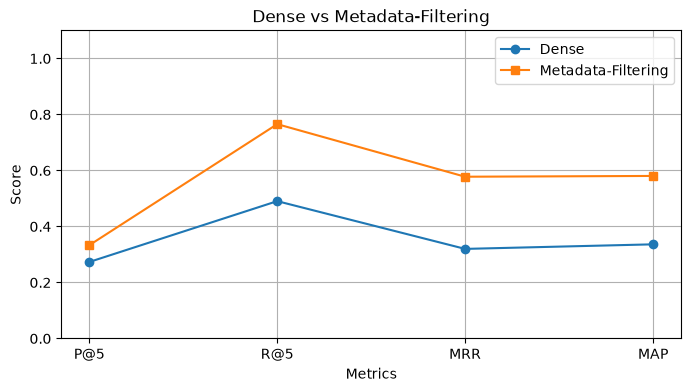

In [37]:
import matplotlib.pyplot as plt

metrics = ['P@5', 'R@5', 'MRR', 'MAP']
dense_vals = [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']]
metadata_vals = [self_query_metrics['P@k'], self_query_metrics['R@k'], self_query_metrics['MRR'], self_query_metrics['MAP']]

x = range(len(metrics))

plt.figure(figsize=(8,4))
plt.plot(x, dense_vals, marker='o', label='Dense')
plt.plot(x,metadata_vals, marker='s', label='Metadata-Filtering')
plt.xticks(x,metrics) # x축 눈금은 0~3 지표명
plt.ylim(0,1.1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Dense vs Metadata-Filtering')
plt.legend()
plt.grid()
plt.show()

## 왜 이런 결과가 나왔나?

- **Dense Retrieval**
  - 문서의 **의미적 유사도**만을 기준으로 판단
  - 작성자(author), 카테고리(category)와 같은 **구조적 조건을 직접 반영하지 못함**

- **Self-Query Retriever (Metadata 기반)**
  - 자연어 질의에서 **조건을 자동으로 추출**
  - 추출된 조건을 **메타데이터 필터로 강제 적용**하여 검색

예를 들어,

> **“이영희가 쓴 여행 관련 글”**

과 같은 질의는  
- Dense Retrieval에게는 의미적으로 **모호한 질문**이지만  
- Metadata 검색에게는 **명확한 조건 기반 질의**가 된다.

---

## 실무 결론 (중요)

### 권장 검색 파이프라인
Self-Query / Metadata Filtering  
↓
Dense Retrieval  
↓
ReRank (선택)

- **조건이 명확한 질의** → Metadata 검색 우선
- **의미적 탐색 중심 질의** → Dense Retrieval 활용
- **실제 서비스 환경** → 두 방식을 결합한 Hybrid 전략 적용

---

## 한 줄 결론 (교안 / 발표용)

> **구조적 조건이 포함된 질의에서는 Dense Retrieval보다 Metadata 기반 검색이 압도적으로 높은 정확도를 보인다.**